# Two plots:
- Total variation bar chart — deltacon, energy, frobenius
- Minima scatter — top-100 per individual subject, subjects shaded by intensity of dataset color

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

from vizman import viz
# viz.set_visual_style()

# CONFIG

# distance_measure = "energy" # 
distance_measure = "delta_con" # energy" # "hamming" # delta_con

base_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")
output_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/00_{distance_measure}_results")
output_path.mkdir(parents=True, exist_ok=True)

from config import COLOR_SCHEME

# η / γ normalisation bounds (same as original script)
ETA_MIN, ETA_MAX     = -3, 8
GAMMA_MIN, GAMMA_MAX = -0.1, 1



# Create this plot for every measure, to compare visually how distributed the dots are for each... 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from vizman import viz

from config import emp_dataset_and_experiment_pairs, LABEL_MAP, PROPERTY_NAMES, COLOR_SCHEME

base_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")



distance_name_in_csv_dict = {
    "hamming": "HammingDist", 
    "delta_con": "DeltaCon", 
    "energy": "MaxCrit"
}
distance_name_in_csv = distance_name_in_csv_dict[distance_measure]

csv_files = {}

datasets_to_look_at = { # emp_dataset_and_experiment_pairs
                    "suarez_MaMI_dataset": "05_mst_animal_0_compared_with_mami", 
                    
                    "lexis_data_developing": "05_mst_animal_0_compared_with_lexis_data_developing", 
                    # "lexis_data_young": "05_mst_animal_0_compared_with_lexis_data_young",
                    # "lexis_data_aging": "05_mst_animal_0_compared_with_lexis_data_aging",
                    
                    # "hcp_schaefer_100_dataset_gnm": "11_mst_2500_animal_0", 
                    # "hcp_schaefer_100_dataset": "05_mst_animal_0_compared_with_hcp_schaefer_100",
                     
                    "kaysons_generated_networks_diffusion": "05_mst_animal_0_compared_with_diffusion", 
                    "kaysons_generated_networks_propagation": "05_mst_animal_0_compared_with_propagation", 
                    #  "kaysons_generated_networks_resistance": "05_mst_animal_0_compared_with_resistance", 
                    "kaysons_generated_networks_routing": "05_mst_animal_0_compared_with_routing", 
                    # "kaysons_generated_networks_topology": "05_mst_animal_0_compared_with_topology", 
                    
                    # "lexis_data_developing_consensus_per_age_1_year": "00_pca",
                    # "lexis_data_young_consensus_per_age_1_year": "00_pca",
                    # "lexis_data_aging_consensus_per_age_1_year": "00_pca",
                    # "lexis_data_all_consensus_per_age_1_year": "00_pca",
                    # "lexis_data_all_consensus_per_age_2_year": "00_pca",
                }


if distance_measure == "energy": 
    datasets_to_look_at = { # emp_dataset_and_experiment_pairs
                        "suarez_MaMI_dataset": "05_mst_animal_0_compared_with_mami", 
                        
                        "lexis_data_developing": "05_mst_animal_0_compared_with_lexis_data_developing", 
                        # "lexis_data_young": "05_mst_animal_0_compared_with_lexis_data_young",
                        # "lexis_data_aging": "05_mst_animal_0_compared_with_lexis_data_aging",
                        
                        # "hcp_schaefer_100_dataset_gnm": "11_mst_2500_animal_0", 
                        # "hcp_schaefer_100_dataset": "05_mst_animal_0_compared_with_hcp_schaefer_100",
                        
                        "kaysons_generated_networks_diffusion": "05_mst_animal_0_compared_with_diffusion", 
                        "kaysons_generated_networks_propagation": "05_mst_animal_0_compared_with_propagation", 
                        #  "kaysons_generated_networks_resistance": "05_mst_animal_0_compared_with_resistance", 
                        "kaysons_generated_networks_routing": "05_mst_animal_0_compared_with_routing", 
                        # "kaysons_generated_networks_topology": "05_mst_animal_0_compared_with_topology", 
                        
                        # "lexis_data_developing_consensus_per_age_1_year": "00_pca",
                        # "lexis_data_young_consensus_per_age_1_year": "00_pca",
                        # "lexis_data_aging_consensus_per_age_1_year": "00_pca",
                        # "lexis_data_all_consensus_per_age_1_year": "00_pca",
                        # "lexis_data_all_consensus_per_age_2_year": "00_pca",
                    }


for dataset_name in datasets_to_look_at: # emp_dataset_and_experiment_pairs
    dataset_folder = dataset_name
    experiment_name = emp_dataset_and_experiment_pairs[dataset_name]
    if dataset_name == "hcp_schaefer_100_dataset_gnm": 
        # dataset_folder = "hcp_schaefer_100_dataset"
        continue
    csv_files[dataset_name] = base_dir / f"{dataset_folder}/{experiment_name}/summary_indiv_{distance_measure}_for_exp_{experiment_name}.csv"
    # if dataset_name == "hcp_schaefer_100_dataset_gnm":
    #     csv_files[dataset_name] = base_dir / f"{dataset_folder}/{experiment_name}/summary_indiv_{distance_measure}_for_exp_{experiment_name}.csv"

# csv_files = {
#     'humans': base_dir / f"hcp_schaefer_100_dataset/05_mst_animal_0_compared_with_hcp_schaefer_100/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_hcp_schaefer_100.csv",
#     'diffusion': base_dir / f"kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusion/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_diffusion.csv",
#     'propagation': base_dir / f"kaysons_generated_networks_propagation/05_mst_animal_0_compared_with_propagation/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_propagation.csv",
#     'routing': base_dir / f"kaysons_generated_networks_routing/05_mst_animal_0_compared_with_routing/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_routing.csv",
#     'mami': base_dir / f"suarez_MaMI_dataset/05_mst_animal_0_compared_with_mami/summary_indiv_{distance_measure}_for_exp_05_mst_animal_0_compared_with_mami.csv"
# }


Processing suarez_MaMI_dataset...
228
  Found 224 minima
Processing lexis_data_developing...
639
  Found 635 minima
Processing kaysons_generated_networks_diffusion...
5
  Found 1 minima
Processing kaysons_generated_networks_propagation...
5
  Found 1 minima
Processing kaysons_generated_networks_routing...
5
  Found 1 minima
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/00_delta_con_results/delta_con_all_datasets.pdf


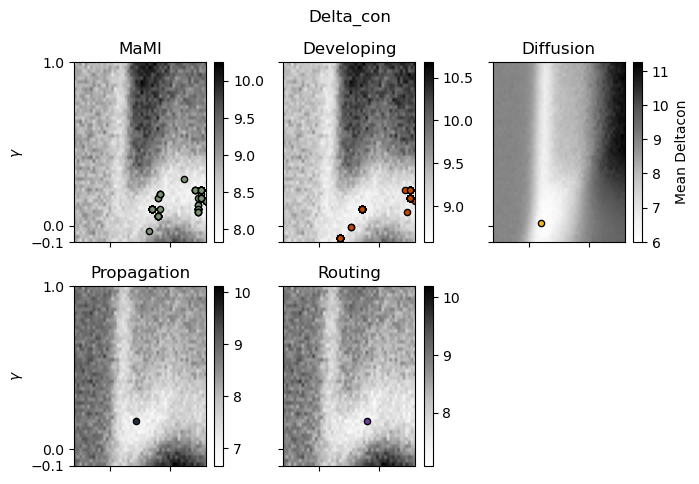

In [3]:
# distance_measure = "energy" # "hamming" # delta_con

# Store all minima for each network type
all_minima = {}

# Do this in subplots
fig, axs = plt.subplots(nrows=3, ncols=3, 
                        figsize=viz.cm_to_inch((18, 18)), 
                        sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

# Process each CSV file
for i, (network_name, get_csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    
    # Load the data
    df = pd.read_csv(get_csv_path)
    
    # Remove all "_x" and "_y" etc from the keys, and remove then all columns that have already appeared (exactly do this for "_x", "_y", "_z")
    # unique_keys = list(set([k.replace("_x", "").replace("_y", "").replace("_z", "")+"_x" for k in df.keys()]) - set(['eta_x', 'filename_x', 'id_x', 'gamma_x', 'network_index_x']))
    # unique_keys = unique_keys + ['eta', 'filename', 'id', 'gamma', 'network_index']
    # df = df[unique_keys]
    keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
    keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
    unique_keys = list(keys)
    unique_keys

    all_keys = set(df.keys())
    # Get the first column-name version for each unique key (e.g. "eta_x" for "eta", "gamma_x" for "gamma", etc.)
    first_versions = []
    for key in unique_keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break

    # print(len(first_versions), len(df.columns))

    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']] # 'filename', 
    
    # # Drop filename column if it exists
    # if 'filename' in df.columns:
    #     df.drop(columns=["filename"], inplace=True)
    
    print(len(df.keys()))
    
    # Group by eta and gamma and calculate mean
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    
    # Find minima for each subject (DeltaCon columns)
    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]

    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    minima_eta = []
    minima_gamma = []
    number_minima = []

    for col in distance_measure_columns:
        # Find the row with minimum DeltaCon for this subject
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])
        # Add the number of minimum values to an array 
        # number_minima.append(df_mean.loc[min_idx, "gamma"].to_numpy())
        # print(np.array(df_mean.loc[min_idx, "gamma"]).shape)

    all_minima[network_name] = {
        'eta': minima_eta,
        'gamma': minima_gamma,
        'df_mean': df_mean, 
        'number_minima': number_minima
    }
    print(f"  Found {len(minima_eta)} minima")
    
    cmap = "Grays"

    # CHANGE SCALING HERE: EITHER FROM 300 to 2300, or for every plot individually. 
    background = axs[i].imshow(df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"), 
                               extent=(df_mean["eta"].min(), df_mean["eta"].max(), df_mean["gamma"].min(), df_mean["gamma"].max()), 
                               origin='lower', aspect='auto', cmap=cmap) # , vmin=300, vmax=2300) # , alpha=0.5)
    
    
    axs[i].set_title(LABEL_MAP[network_name]) # .capitalize())
    if i in [0, 3, 6]:  # left column
        axs[i].set_ylabel(PROPERTY_NAMES["gamma"])
        axs[i].set_yticks([-0.1, 0, 1])
    if i in [6, 7]: 
        axs[i].set_xlabel(PROPERTY_NAMES["eta"])
        axs[i].set_xticks([-8, 0, 3])
        
    # axs[i].set_ylabel(PROPERTY_NAMES["gamma"])
    if i in [2,5]: 
        plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")
    else: 
        plt.colorbar(background, ax=axs[i])

    # Add minima points
    axs[i].scatter(minima_eta, minima_gamma, 
                   color=COLOR_SCHEME[network_name], # 'red', 
                   s=20, 
                   label='Minima', 
                   edgecolor='black')

# Remove empty subplot
if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.suptitle(f"{distance_measure.capitalize()}") # .replace(" ", "")}")
plt.tight_layout()
plt.savefig(output_path / f"{distance_measure}_all_datasets.pdf", bbox_inches="tight")
print(output_path / f"{distance_measure}_all_datasets.pdf")


Processing suarez_MaMI_dataset...
228
  Found 224 minima
Processing lexis_data_developing...
639
  Found 635 minima
Processing kaysons_generated_networks_diffusion...
5
  Found 1 minima
Processing kaysons_generated_networks_propagation...
5
  Found 1 minima
Processing kaysons_generated_networks_routing...
5
  Found 1 minima


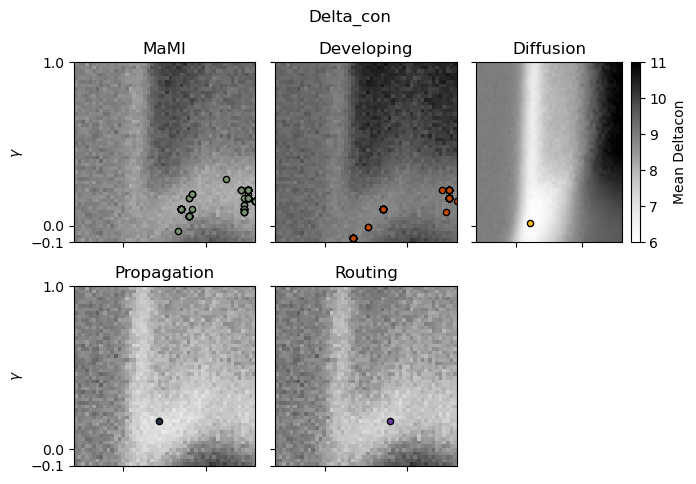

In [4]:
# SHARED COLORBAR

# distance_measure = "energy" # "hamming" # delta_con

# Store all minima for each network type
all_minima = {}

# Do this in subplots
fig, axs = plt.subplots(nrows=3, ncols=3, 
                        figsize=viz.cm_to_inch((18, 18)), 
                        sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

# Process each CSV file
for i, (network_name, get_csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    
    # Load the data
    df = pd.read_csv(get_csv_path)
    
    # Remove all "_x" and "_y" etc from the keys, and remove then all columns that have already appeared (exactly do this for "_x", "_y", "_z")
    # unique_keys = list(set([k.replace("_x", "").replace("_y", "").replace("_z", "")+"_x" for k in df.keys()]) - set(['eta_x', 'filename_x', 'id_x', 'gamma_x', 'network_index_x']))
    # unique_keys = unique_keys + ['eta', 'filename', 'id', 'gamma', 'network_index']
    # df = df[unique_keys]
    keys = set([k.replace("_x", "").replace("_y", "").replace("_z", "") for k in df.keys()])
    keys = keys - set(['eta', 'filename', 'id', 'gamma', 'network_index'])
    unique_keys = list(keys)
    unique_keys

    all_keys = set(df.keys())
    # Get the first column-name version for each unique key (e.g. "eta_x" for "eta", "gamma_x" for "gamma", etc.)
    first_versions = []
    for key in unique_keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break

    # print(len(first_versions), len(df.columns))

    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']] # 'filename', 
    
    # # Drop filename column if it exists
    # if 'filename' in df.columns:
    #     df.drop(columns=["filename"], inplace=True)
    
    print(len(df.keys()))
    
    # Group by eta and gamma and calculate mean
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    
    # Find minima for each subject (DeltaCon columns)
    distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]

    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    minima_eta = []
    minima_gamma = []
    number_minima = []

    for col in distance_measure_columns:
        # Find the row with minimum DeltaCon for this subject
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])
        # Add the number of minimum values to an array 
        # number_minima.append(df_mean.loc[min_idx, "gamma"].to_numpy())
        # print(np.array(df_mean.loc[min_idx, "gamma"]).shape)

    all_minima[network_name] = {
        'eta': minima_eta,
        'gamma': minima_gamma,
        'df_mean': df_mean, 
        'number_minima': number_minima
    }
    print(f"  Found {len(minima_eta)} minima")
    
    cmap = "Grays"

    # CHANGE SCALING HERE: EITHER FROM 300 to 2300, or for every plot individually. 
    background = axs[i].imshow(df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean"), 
                               extent=(df_mean["eta"].min(), df_mean["eta"].max(), df_mean["gamma"].min(), df_mean["gamma"].max()), 
                               origin='lower', aspect='auto', cmap=cmap, 
                               vmin=6, vmax=11
                               ) # , vmin=300, vmax=2300) # , alpha=0.5)
    
    
    axs[i].set_title(LABEL_MAP[network_name]) # .capitalize())
    if i in [0, 3, 6]:  # left column
        axs[i].set_ylabel(PROPERTY_NAMES["gamma"])
        axs[i].set_yticks([-0.1, 0, 1])
    if i in [6, 7]: 
        axs[i].set_xlabel(PROPERTY_NAMES["eta"])
        axs[i].set_xticks([-8, 0, 3])
        
    # axs[i].set_ylabel(PROPERTY_NAMES["gamma"])
    if i in [2,5]: 
        plt.colorbar(background, ax=axs[i], label=f"Mean {distance_name_in_csv.capitalize()}")
    # else: 
        # plt.colorbar(background, ax=axs[i])

    # Add minima points
    axs[i].scatter(minima_eta, minima_gamma, 
                   color=COLOR_SCHEME[network_name], # 'red', 
                   s=20, 
                   label='Minima', 
                   edgecolor='black')

# Remove empty subplot
if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.suptitle(f"{distance_measure.capitalize()}") # .replace(" ", "")}")
plt.tight_layout()
# plt.savefig(output_path / f"energy_all_datasets.pdf", bbox_inches="tight")
# print(output_path / f"energy_all_datasets.pdf")


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/00_delta_con_results/delta_con_boxplot_lowest_100_values.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_62663/3810158407.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxplot_data, labels=labels,


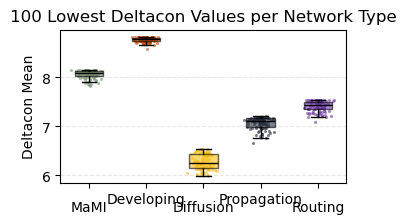


SUMMARY STATISTICS (100 LOWEST VALUES)

SUAREZ_MAMI_DATASET:
  Min: 7.829144
  Q1 (25th percentile): 8.031941
  Median: 8.085694
  Q3 (75th percentile): 8.126726
  Max: 8.158254
  Mean ± std: 8.066309 ± 0.078476

LEXIS_DATA_DEVELOPING:
  Min: 8.576773
  Q1 (25th percentile): 8.744442
  Median: 8.785774
  Q3 (75th percentile): 8.809210
  Max: 8.832673
  Mean ± std: 8.773673 ± 0.046508

KAYSONS_GENERATED_NETWORKS_DIFFUSION:
  Min: 5.994739
  Q1 (25th percentile): 6.156512
  Median: 6.256795
  Q3 (75th percentile): 6.438488
  Max: 6.539442
  Mean ± std: 6.280198 ± 0.157051

KAYSONS_GENERATED_NETWORKS_PROPAGATION:
  Min: 6.662739
  Q1 (25th percentile): 6.988849
  Median: 7.103365
  Q3 (75th percentile): 7.161129
  Max: 7.204120
  Mean ± std: 7.062395 ± 0.116897

KAYSONS_GENERATED_NETWORKS_ROUTING:
  Min: 7.086381
  Q1 (25th percentile): 7.350262
  Median: 7.434159
  Q3 (75th percentile): 7.503655
  Max: 7.546211
  Mean ± std: 7.412952 ± 0.108571


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Collect the 100 lowest DeltaCon values for each network type
boxplot_data = []
labels = []

# colors_list = ['red', 'blue', 'green', 'orange', 'purple']
colors_list = []
# network_types = ['diffusion', 'mami', 'routing', 'propagation', 'humans']

for network_name in all_minima: # network_types:
    df_mean = all_minima[network_name]['df_mean']
    
    # Ensure DeltaCon_mean exists
    if f'{distance_name_in_csv}_mean' not in df_mean.columns:
        distance_measure_columns = [col for col in df_mean.columns if f"{distance_name_in_csv}_subject_" in col]
        df_mean[f'{distance_name_in_csv}_mean'] = df_mean[distance_measure_columns].mean(axis=1)

    # Get the 100 lowest values from the ENTIRE dataframe
    lowest_100 = df_mean[f'{distance_name_in_csv}_mean'].nsmallest(100).values
    boxplot_data.append(lowest_100)
    labels.append(LABEL_MAP[network_name]) # .capitalize())
    colors_list.append(COLOR_SCHEME[network_name])

# Create the boxplot
fig, ax = plt.subplots(figsize=viz.cm_to_inch((9,6)), dpi=100)

# Add scatter points for the 100 lowest values
for i, data in enumerate(boxplot_data):
    x = np.random.normal(i + 1, 0.1, # 04, 
                         size=len(data))  # Jitter the x-values
    ax.scatter(x, data, color=colors_list[i], 
               s=5, 
               alpha=0.6, 
               edgecolor='black', 
               linewidth=0, # 0.5
               )
   
# Box plot
bp = ax.boxplot(boxplot_data, labels=labels, 
                patch_artist=True, showfliers=False, # to hide outliers
                # showmeans=True, meanline=False,
                medianprops=dict(color='black', 
                                 linewidth=1
                                 ),
                # meanprops=dict(marker='.',  # D
                #                markerfacecolor='white', 
                #                markeredgecolor='black', 
                #                markersize=6
                #                )
                )

# Color the boxes
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel(f'{distance_name_in_csv.capitalize()} Mean')
# Set every second tick a bit lower to avoid overlap
for tick in ax.get_xticklabels()[::2]:
    tick.set_y(tick.get_position()[1] - 0.05)
ax.set_xticklabels(labels, # rotation=45, 
                   ha='center') # right')

ax.set_title(f'100 Lowest {distance_name_in_csv.capitalize()} Values per Network Type')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(output_path / f"{distance_measure}_boxplot_lowest_100_values.pdf", bbox_inches="tight")
print(output_path / f"{distance_measure}_boxplot_lowest_100_values.pdf")
plt.show()

# Print summary statistics for the 100 lowest values
print("\n" + "="*60)
print("SUMMARY STATISTICS (100 LOWEST VALUES)")
print("="*60)
for i, network_name in enumerate(all_minima.keys()):
    data = boxplot_data[i]
    print(f"\n{network_name.upper()}:")
    print(f"  Min: {np.min(data):.6f}")
    print(f"  Q1 (25th percentile): {np.percentile(data, 25):.6f}")
    print(f"  Median: {np.median(data):.6f}")
    print(f"  Q3 (75th percentile): {np.percentile(data, 75):.6f}")
    print(f"  Max: {np.max(data):.6f}")
    print(f"  Mean ± std: {np.mean(data):.6f} ± {np.std(data):.6f}")
    


In [6]:

# from mpl_toolkits.axes_grid1 import make_axes_locatable


# # ── Combined figure using subplot_mosaic ──────────────────────────────────────

# network_names = list(csv_files.keys())   # 7 entries expected

# # Build mosaic layout: 7 heatmap panels + 1 wide boxplot (bottom-right 2 cells)
# if distance_measure == "energy": 
#    mosaic = [
#         [network_names[0], network_names[1], network_names[2]],
#         [network_names[3], 'boxplot',        'boxplot'       ],
#     ]
#    figsize = viz.cm_to_inch((18, 12))

# else: 
#     mosaic = [
#         [network_names[0], network_names[1], network_names[2]],
#         [network_names[3], network_names[4], network_names[5]],
#         [network_names[6], 'boxplot',        'boxplot'       ],
#     ]
#     figsize = viz.cm_to_inch((18, 18))

# fig, axs = plt.subplot_mosaic(
#     mosaic,
#     figsize=figsize,
#     dpi=100,
# )

# # ── shared axis limits (applied manually since mosaic doesn't do sharex/sharey) ──
# X_MIN, X_MAX = None, None   # will be set from first dataset
# Y_MIN, Y_MAX = None, None

# # ── 1. Heatmap panels ─────────────────────────────────────────────────────────
# all_minima = {}

# for pos_idx, (network_name, get_csv_path) in enumerate(csv_files.items()):
#     print(f"Processing {network_name}...")
#     ax = axs[network_name]

#     # ── Load & deduplicate columns ────────────────────────────────────────────
#     df = pd.read_csv(get_csv_path)
#     all_keys = set(df.keys())
#     keys = set([k.replace("_x","").replace("_y","").replace("_z","") for k in all_keys])
#     keys -= {'eta', 'filename', 'id', 'gamma', 'network_index'}
#     first_versions = []
#     for key in keys:
#         for suffix in ["", "_x", "_y", "_z"]:
#             candidate = key + suffix
#             if candidate in all_keys:
#                 first_versions.append(candidate)
#                 break
#     df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']]
#     print(f"  {len(df.keys())} columns retained")

#     df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()

#     # Update shared axis limits
#     if X_MIN is None:
#         X_MIN, X_MAX = df_mean["eta"].min(),   df_mean["eta"].max()
#         Y_MIN, Y_MAX = df_mean["gamma"].min(), df_mean["gamma"].max()

#     # ── Per-subject minima ────────────────────────────────────────────────────
#     distance_measure_columns = [c for c in df_mean.columns if f"{distance_name_in_csv}_subject_" in c]
#     df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

#     minima_eta, minima_gamma = [], []
#     for col in distance_measure_columns:
#         min_idx = df_mean[col].idxmin()
#         minima_eta.append(df_mean.loc[min_idx, "eta"])
#         minima_gamma.append(df_mean.loc[min_idx, "gamma"])

#     all_minima[network_name] = {
#         'eta': minima_eta, 'gamma': minima_gamma,
#         'df_mean': df_mean,
#     }
#     print(f"  Found {len(minima_eta)} minima")

#     # ── Heatmap ───────────────────────────────────────────────────────────────
#     pivot = df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean")
#     im = ax.imshow(
#         pivot,
#         extent=(df_mean["eta"].min(), df_mean["eta"].max(),
#                 df_mean["gamma"].min(), df_mean["gamma"].max()),
#         origin='lower', aspect='auto', cmap="Grays",
#     )
#     ax.set_title(LABEL_MAP[network_name])

#     # Determine grid position for axis-label / tick decisions
#     col_idx = mosaic[pos_idx // 3][pos_idx % 3]   # same as network_name
#     row = pos_idx // 3
#     col = pos_idx % 3

#     if col == 0:
#         ax.set_ylabel(PROPERTY_NAMES["gamma"])
#         ax.set_yticks([-0.1, 0, 1])
#     else:
#         ax.set_yticks([])

#     if row == 2:                         # bottom row (only Routing here)
#         ax.set_xlabel(PROPERTY_NAMES["eta"])
#         ax.set_xticks([-8, 0, 3])
#     else:
#         ax.set_xticks([])

#     # # Colorbar on right column panels only
#     # if col == 2:
#     #     plt.colorbar(im, ax=ax, label=f"Mean {distance_name_in_csv.capitalize()}")
#     # else:
#     #     plt.colorbar(im, ax=ax)


#     # Replace every colorbar call inside the heatmap loop with this pattern:
#     divider = make_axes_locatable(ax)
#     cax = divider.append_axes("right", size="5%", pad=0.05)

#     if col == 2:
#         plt.colorbar(im, cax=cax, label=f"Mean {distance_name_in_csv.capitalize()}")
#     else:
#         plt.colorbar(im, cax=cax)
        
#     # ── Scatter minima ────────────────────────────────────────────────────────
#     ax.scatter(minima_eta, minima_gamma,
#                color=COLOR_SCHEME[network_name],
#                s=20, label='Minima', edgecolor='black')

#     # Enforce shared limits
#     ax.set_xlim(X_MIN, X_MAX)
#     ax.set_ylim(Y_MIN, Y_MAX)





# # ── 2. Boxplot panel ──────────────────────────────────────────────────────────
# ax_box = axs['boxplot']

# boxplot_data, labels, colors_list = [], [], []

# for network_name in all_minima:
#     df_mean = all_minima[network_name]['df_mean']
#     if f'{distance_name_in_csv}_mean' not in df_mean.columns:
#         dcols = [c for c in df_mean.columns if f"{distance_name_in_csv}_subject_" in c]
#         df_mean[f'{distance_name_in_csv}_mean'] = df_mean[dcols].mean(axis=1)

#     lowest_100 = df_mean[f'{distance_name_in_csv}_mean'].nsmallest(100).values
#     boxplot_data.append(lowest_100)
#     labels.append(LABEL_MAP[network_name])
#     colors_list.append(COLOR_SCHEME[network_name])

# # Scatter jitter
# for i, data in enumerate(boxplot_data):
#     x = np.random.normal(i + 1, 0.1, size=len(data))
#     ax_box.scatter(x, data, color=colors_list[i],
#                    s=5, alpha=0.6, edgecolor='black', linewidth=0)

# bp = ax_box.boxplot(
#     boxplot_data, labels=labels,
#     patch_artist=True, showfliers=False,
#     medianprops=dict(color='black', linewidth=1),
# )
# for patch, color in zip(bp['boxes'], colors_list):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.6)

# ax_box.set_ylabel(f'{distance_name_in_csv.capitalize()} Mean')
# ax_box.set_title(f'100 Lowest {distance_name_in_csv.capitalize()} Values per Network Type')
# ax_box.grid(axis='y', alpha=0.3, linestyle='--')

# # Stagger every other x-tick label slightly lower to avoid overlap
# for j, tick in enumerate(ax_box.get_xticklabels()):
#     if j % 2 == 0:
#         tick.set_y(tick.get_position()[1] - 0.05)

# # After building the boxplot, balance its width to match heatmap columns:
# # divider = make_axes_locatable(ax_box)
# # cax_dummy = divider.append_axes("right", size="5%", pad=0.05)
# # cax_dummy.set_visible(False) 

# # ── Final touches ─────────────────────────────────────────────────────────────
# plt.suptitle(distance_name_in_csv.capitalize())
# plt.tight_layout()
# plt.savefig(output_path / f"{distance_name_in_csv}_combined_mosaic.pdf", bbox_inches="tight")
# print(output_path / f"{distance_name_in_csv}_combined_mosaic.pdf")
# plt.show()

Processing suarez_MaMI_dataset...
  228 columns retained
  Found 224 minima
Processing lexis_data_developing...
  639 columns retained
  Found 635 minima
Processing kaysons_generated_networks_diffusion...
  5 columns retained
  Found 1 minima
Processing kaysons_generated_networks_propagation...
  5 columns retained
  Found 1 minima
Processing kaysons_generated_networks_routing...
  5 columns retained
  Found 1 minima


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_62663/1503269628.py:183: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/00_delta_con_results/DeltaCon_combined_mosaic_only_developing.pdf


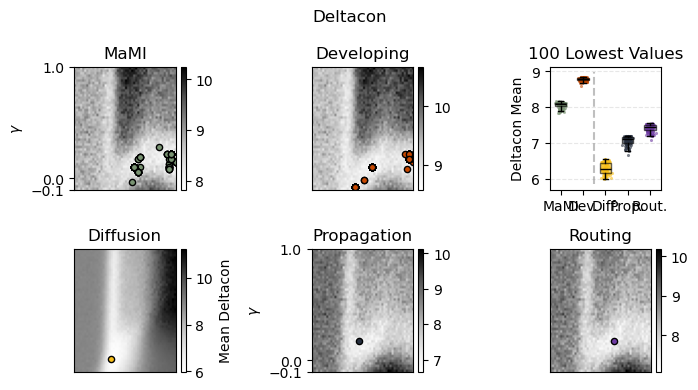

In [7]:

from mpl_toolkits.axes_grid1 import make_axes_locatable


datasets_to_look_at = { # emp_dataset_and_experiment_pairs
                    "suarez_MaMI_dataset": "05_mst_animal_0_compared_with_mami", 
                    
                    "lexis_data_developing": "05_mst_animal_0_compared_with_lexis_data_developing", 
                    # "lexis_data_young": "05_mst_animal_0_compared_with_lexis_data_young",
                    # "lexis_data_aging": "05_mst_animal_0_compared_with_lexis_data_aging",
                    
                    # "hcp_schaefer_100_dataset_gnm": "11_mst_2500_animal_0", 
                    # "hcp_schaefer_100_dataset": "05_mst_animal_0_compared_with_hcp_schaefer_100",
                     
                    "kaysons_generated_networks_diffusion": "05_mst_animal_0_compared_with_diffusion", 
                    "kaysons_generated_networks_propagation": "05_mst_animal_0_compared_with_propagation", 
                    #  "kaysons_generated_networks_resistance": "05_mst_animal_0_compared_with_resistance", 
                    "kaysons_generated_networks_routing": "05_mst_animal_0_compared_with_routing", 
                    # "kaysons_generated_networks_topology": "05_mst_animal_0_compared_with_topology", 
                    
                    # "lexis_data_developing_consensus_per_age_1_year": "00_pca",
                    # "lexis_data_young_consensus_per_age_1_year": "00_pca",
                    # "lexis_data_aging_consensus_per_age_1_year": "00_pca",
                    # "lexis_data_all_consensus_per_age_1_year": "00_pca",
                    # "lexis_data_all_consensus_per_age_2_year": "00_pca",
                }

# ── Combined figure using subplot_mosaic ──────────────────────────────────────

network_names = list(datasets_to_look_at.keys()) # list(csv_files.keys())   # 7 entries expected

# csv_files: only have the ones that have the network_names names
# csv_files = {name: path for name, path in csv_files.items() if name in network_names}
csv_files = {name: csv_files[name]for name in list(datasets_to_look_at.keys()) if name in network_names}
# Build mosaic layout: 7 heatmap panels + 1 wide boxplot (bottom-right 2 cells)
if distance_measure == "energy": 
   mosaic = [
        [network_names[0], network_names[1], network_names[2]],
        [network_names[3], 'boxplot',        'boxplot'       ],
    ]
   figsize = viz.cm_to_inch((18, 12))

else: 
    mosaic = [
        [network_names[0], network_names[1], 'boxplot'],
        [network_names[2], network_names[3], network_names[4]],
    ]
    figsize = viz.cm_to_inch((18, 10))

fig, axs = plt.subplot_mosaic(
    mosaic,
    figsize=figsize,
    dpi=100,
)

# ── shared axis limits (applied manually since mosaic doesn't do sharex/sharey) ──
X_MIN, X_MAX = None, None   # will be set from first dataset
Y_MIN, Y_MAX = None, None

# ── 1. Heatmap panels ─────────────────────────────────────────────────────────
all_minima = {}

# for pos_idx, network_name in enumerate(network_names): # 
for pos_idx, (network_name, get_csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    ax = axs[network_name]

    # ── Load & deduplicate columns ────────────────────────────────────────────
    df = pd.read_csv(get_csv_path)
    all_keys = set(df.keys())
    keys = set([k.replace("_x","").replace("_y","").replace("_z","") for k in all_keys])
    keys -= {'eta', 'filename', 'id', 'gamma', 'network_index'}
    first_versions = []
    for key in keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break
    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']]
    print(f"  {len(df.keys())} columns retained")

    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()

    # Update shared axis limits
    if X_MIN is None:
        X_MIN, X_MAX = df_mean["eta"].min(),   df_mean["eta"].max()
        Y_MIN, Y_MAX = df_mean["gamma"].min(), df_mean["gamma"].max()

    # ── Per-subject minima ────────────────────────────────────────────────────
    distance_measure_columns = [c for c in df_mean.columns if f"{distance_name_in_csv}_subject_" in c]
    df_mean[f"{distance_name_in_csv}_mean"] = df_mean[distance_measure_columns].mean(axis=1)

    minima_eta, minima_gamma = [], []
    for col in distance_measure_columns:
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])

    all_minima[network_name] = {
        'eta': minima_eta, 'gamma': minima_gamma,
        'df_mean': df_mean,
    }
    print(f"  Found {len(minima_eta)} minima")

    # ── Heatmap ───────────────────────────────────────────────────────────────
    pivot = df_mean.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean")
    im = ax.imshow(
        pivot,
        extent=(df_mean["eta"].min(), df_mean["eta"].max(),
                df_mean["gamma"].min(), df_mean["gamma"].max()),
        origin='lower', aspect='auto', cmap="Grays",
    )
    ax.set_title(LABEL_MAP[network_name])

    # Determine grid position for axis-label / tick decisions
    col_idx = mosaic[pos_idx // 3][pos_idx % 3]   # same as network_name
    row = pos_idx // 3
    col = pos_idx % 3

    if col == 0:
        ax.set_ylabel(PROPERTY_NAMES["gamma"])
        ax.set_yticks([-0.1, 0, 1])
    else:
        ax.set_yticks([])

    if row == 2:                         # bottom row (only Routing here)
        ax.set_xlabel(PROPERTY_NAMES["eta"])
        ax.set_xticks([-8, 0, 3])
    else:
        ax.set_xticks([])

    # # Colorbar on right column panels only
    # if col == 2:
    #     plt.colorbar(im, ax=ax, label=f"Mean {distance_name_in_csv.capitalize()}")
    # else:
    #     plt.colorbar(im, ax=ax)


    # Replace every colorbar call inside the heatmap loop with this pattern:
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    if col == 2:
        plt.colorbar(im, cax=cax, label=f"Mean {distance_name_in_csv.capitalize()}")
    else:
        plt.colorbar(im, cax=cax)
        
    # ── Scatter minima ────────────────────────────────────────────────────────
    ax.scatter(minima_eta, minima_gamma,
               color=COLOR_SCHEME[network_name],
               s=20, label='Minima', edgecolor='black')

    # Enforce shared limits
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)





# ── 2. Boxplot panel ──────────────────────────────────────────────────────────
ax_box = axs['boxplot']

boxplot_data, labels, colors_list = [], [], []

for network_name in all_minima:
    df_mean = all_minima[network_name]['df_mean']
    if f'{distance_name_in_csv}_mean' not in df_mean.columns:
        dcols = [c for c in df_mean.columns if f"{distance_name_in_csv}_subject_" in c]
        df_mean[f'{distance_name_in_csv}_mean'] = df_mean[dcols].mean(axis=1)

    lowest_100 = df_mean[f'{distance_name_in_csv}_mean'].nsmallest(100).values
    boxplot_data.append(lowest_100)
    labels.append(LABEL_MAP[network_name])
    colors_list.append(COLOR_SCHEME[network_name])

# Scatter jitter
for i, data in enumerate(boxplot_data):
    x = np.random.normal(i + 1, 0.1, size=len(data))
    ax_box.scatter(x, data, color=colors_list[i],
                   s=5, alpha=0.6, edgecolor='black', linewidth=0)

bp = ax_box.boxplot(
    boxplot_data, labels=labels,
    patch_artist=True, showfliers=False,
    medianprops=dict(color='black', linewidth=1),
)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax_box.set_ylabel(f'{distance_name_in_csv.capitalize()} Mean')
# ax_box.set_title(f'100 Lowest {distance_name_in_csv.capitalize()} Values') #  per Network Type')
ax_box.set_title(f'100 Lowest Values') #  per Network Type')
ax_box.grid(axis='y', alpha=0.3, linestyle='--')

new_labels = ["MaMI", "Dev.", "Diff.", "Prop.", "Rout."]
ax_box.set_xticklabels(new_labels, ha='center') # rotation=45,
# Stagger every other x-tick label slightly lower to avoid overlap
# for j, tick in enumerate(ax_box.get_xticklabels()):
#     if j % 2 == 0:
#         tick.set_y(tick.get_position()[1] - 0.05)
ax_box.vlines(2.5, *ax_box.get_ylim(), colors='gray', linestyles='dashed', alpha=0.5)

# After building the boxplot, balance its width to match heatmap columns:
# divider = make_axes_locatable(ax_box)
# cax_dummy = divider.append_axes("right", size="5%", pad=0.05)
# cax_dummy.set_visible(False) 

# ── Final touches ─────────────────────────────────────────────────────────────
plt.suptitle(distance_name_in_csv.capitalize())
plt.tight_layout()
plt.savefig(output_path / f"{distance_name_in_csv}_combined_mosaic_only_developing.pdf", bbox_inches="tight")
print(output_path / f"{distance_name_in_csv}_combined_mosaic_only_developing.pdf")
plt.show()

# Indiviudal GNM networks

Processing suarez_MaMI_dataset...
  228 columns retained
  Found 224 minima
Processing lexis_data_developing...
  639 columns retained
  Found 635 minima
Processing kaysons_generated_networks_diffusion...
  5 columns retained
  Found 1 minima
kaysons_generated_networks_diffusion Min eta: [-3.73] Min gamma: [0.06] Min distance: [5.6]
Processing kaysons_generated_networks_propagation...
  5 columns retained
  Found 1 minima
kaysons_generated_networks_propagation Min eta: [-4.18] Min gamma: [0.44] Min distance: [5.56]
Processing kaysons_generated_networks_routing...
  5 columns retained
  Found 1 minima
kaysons_generated_networks_routing Min eta: [-1.49] Min gamma: [0.21] Min distance: [5.82]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_62663/2599970453.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/00_delta_con_results/DeltaCon_combined_mosaic_not_meaned.pdf


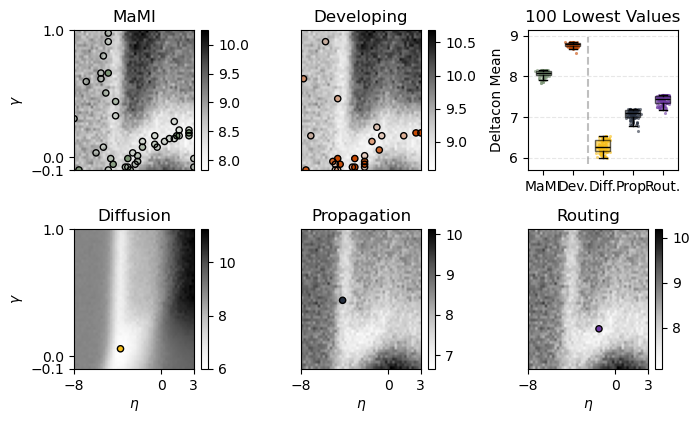

In [8]:
network_names = list(csv_files.keys())   # 7 entries expected

fig, axs = plt.subplot_mosaic(
    mosaic,
    figsize=viz.cm_to_inch((18, 11)),
    dpi=100,
)

# ── 1. Heatmap panels ─────────────────────────────────────────────────────────
all_minima = {}

for pos_idx, (network_name, get_csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    ax = axs[network_name]

    # ── Load & deduplicate columns ────────────────────────────────────────────
    df = pd.read_csv(get_csv_path)
    all_keys = set(df.keys())
    keys = set([k.replace("_x","").replace("_y","").replace("_z","") for k in all_keys])
    keys -= {'eta', 'filename', 'id', 'gamma', 'network_index'}
    first_versions = []
    for key in keys:
        for suffix in ["", "_x", "_y", "_z"]:
            candidate = key + suffix
            if candidate in all_keys:
                first_versions.append(candidate)
                break
    df = df[first_versions + ['eta', 'id', 'gamma', 'network_index']]
    print(f"  {len(df.keys())} columns retained")

    # df_mean = df # 
    df_mean_2 = df.groupby(["eta", "gamma"]).mean().reset_index()

    # Update shared axis limits
    if X_MIN is None:
        X_MIN, X_MAX = df_mean_2["eta"].min(),   df_mean_2["eta"].max()
        Y_MIN, Y_MAX = df_mean_2["gamma"].min(), df_mean_2["gamma"].max()

    # ── Per-subject minima ────────────────────────────────────────────────────
    distance_measure_columns = [c for c in df_mean_2.columns if f"{distance_name_in_csv}_subject_" in c]
    df_mean_2[f"{distance_name_in_csv}_mean"] = df_mean_2[distance_measure_columns].mean(axis=1)

    minima_eta, minima_gamma, minima_distances = [], [], []
    for col in distance_measure_columns:
        min_idx = df[col].idxmin()
        minima_eta.append(df.loc[min_idx, "eta"])
        minima_gamma.append(df.loc[min_idx, "gamma"])
        minima_distances.append(df.loc[min_idx, col])

    all_minima[network_name] = {
        'eta': minima_eta, 'gamma': minima_gamma,
        'df_mean': df_mean_2, # .loc[min_idx, "eta"],
        'minima_distances': minima_distances
    }
    print(f"  Found {len(minima_eta)} minima")

    # ── Heatmap ───────────────────────────────────────────────────────────────
    pivot = df_mean_2.pivot(index="gamma", columns="eta", values=f"{distance_name_in_csv}_mean")
    im = ax.imshow(
        pivot,
        extent=(df_mean_2["eta"].min(), df_mean_2["eta"].max(),
                df_mean_2["gamma"].min(), df_mean_2["gamma"].max()),
        origin='lower', aspect='auto', cmap="Grays",
    )
    ax.set_title(LABEL_MAP[network_name])

    # Determine grid position for axis-label / tick decisions
    col_idx = mosaic[pos_idx // 3][pos_idx % 3]   # same as network_name
    row = pos_idx // 3
    col = pos_idx % 3

    if pos_idx == 0 or pos_idx == 2: # left column
        ax.set_ylabel(PROPERTY_NAMES["gamma"])
        ax.set_yticks([-0.1, 0, 1])
    else:
        ax.set_yticks([])

    if pos_idx in [2, 3, 4]:                         # bottom row (only Routing here)
        ax.set_xlabel(PROPERTY_NAMES["eta"])
        ax.set_xticks([-8, 0, 3])
    else:
        ax.set_xticks([])

    # Colorbar on right column panels only
    # if col == 2:
    if pos_idx == 5: 
        plt.colorbar(im, ax=ax, label=f"Mean {distance_name_in_csv.capitalize()}")
    else:
        plt.colorbar(im, ax=ax)

    # MINIMA Scatter
    ax.scatter(minima_eta, minima_gamma,
               color=COLOR_SCHEME[network_name],
               s=20, label='Minima', edgecolor="none", # 'black', 
               alpha=1 if "kayson" in network_name else 0.2
               )
    # Get unique minima points (since some subjects might share the same minima)
    unique_points = set(zip(minima_eta, minima_gamma))
    ax.scatter(*zip(*unique_points),
               color="none", # COLOR_SCHEME[network_name],
               s=20, label='Minima', 
               edgecolor='black', 
               alpha=1)
    
    
    # LIGHT GREEN DOT SHOWING WHERE DEVELOPING CLUSTERS APPROXIMATELY
    # # plot point (-4, 0.5) in light green to indicate the location of the minima for the developing dataset, which is not included in this plot but serves as a reference point.
    # x_pos = -4
    # y_pos = -0.05  # just inside the bottom of the gamma range
    # ax.scatter([x_pos], [y_pos], color="lightgreen", s=40, edgecolor="black")

    if "kayson" in network_name:
        print(network_name, "Min eta:", np.round(minima_eta, 2), 
                            "Min gamma:", np.round(minima_gamma, 2),
                            "Min distance:", np.round(minima_distances, 2))
    # Enforce shared limits
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    




# ── 2. Boxplot panel ──────────────────────────────────────────────────────────
ax_box = axs['boxplot']

boxplot_data, labels, colors_list = [], [], []

for network_name in all_minima:
    df_mean = all_minima[network_name]['df_mean']
    if f'{distance_name_in_csv}_mean' not in df_mean.columns:
        dcols = [c for c in df_mean.columns if f"{distance_name_in_csv}_subject_" in c]
        df_mean[f'{distance_name_in_csv}_mean'] = df_mean[dcols].mean(axis=1)

    lowest_100 = df_mean[f'{distance_name_in_csv}_mean'].nsmallest(100).values
    boxplot_data.append(lowest_100)
    labels.append(LABEL_MAP[network_name])
    colors_list.append(COLOR_SCHEME[network_name])

# Scatter jitter
for i, data in enumerate(boxplot_data):
    x = np.random.normal(i + 1, 0.1, size=len(data))
    ax_box.scatter(x, data, color=colors_list[i],
                   s=5, alpha=0.6, edgecolor='black', linewidth=0)

bp = ax_box.boxplot(
    boxplot_data, labels=labels,
    patch_artist=True, showfliers=False,
    medianprops=dict(color='black', linewidth=1),
)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax_box.set_ylabel(f'{distance_name_in_csv.capitalize()} Mean')
# ax_box.set_title(f'100 Lowest {distance_name_in_csv.capitalize()} Values') #  per Network Type')
ax_box.set_title(f'100 Lowest Values') #  per Network Type')
ax_box.grid(axis='y', alpha=0.3, linestyle='--')

new_labels = ["MaMI", "Dev.", "Diff.", "Prop.", "Rout."]
ax_box.set_xticklabels(new_labels, ha='center') # rotation=45,
# Stagger every other x-tick label slightly lower to avoid overlap
# for j, tick in enumerate(ax_box.get_xticklabels()):
#     if j % 2 == 0:
#         tick.set_y(tick.get_position()[1] - 0.05)
ax_box.vlines(2.5, *ax_box.get_ylim(), colors='gray', linestyles='dashed', alpha=0.5)

# After building the boxplot, balance its width to match heatmap columns:
# divider = make_axes_locatable(ax_box)
# cax_dummy = divider.append_axes("right", size="5%", pad=0.05)
# cax_dummy.set_visible(False) 

# ── Final touches ─────────────────────────────────────────────────────────────
# plt.suptitle("   ") # distance_name_in_csv.capitalize())
plt.tight_layout()
plt.savefig(output_path / f"{distance_name_in_csv}_combined_mosaic_not_meaned.pdf", bbox_inches="tight")
print(output_path / f"{distance_name_in_csv}_combined_mosaic_not_meaned.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/00_delta_con_results/mami_deltacon_minima_by_order.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_62663/637784512.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10_r", len(names)) # "RdYlGn_r", len(names))


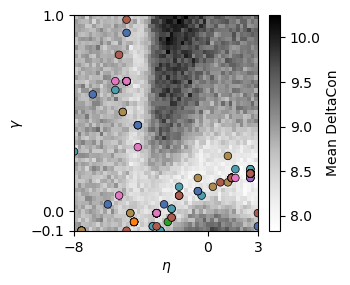

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(csv_files["suarez_MaMI_dataset"])
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv") 

names = info_mami["order"].unique()

color_map = plt.cm.get_cmap("tab10_r", len(names)) # "RdYlGn_r", len(names))
color_dict = {name: color_map(i) for i, name in enumerate(names)}


color_dict["Primates"] = "#AD5C4D"
color_dict["Rodentia"] = "#AD8B4E"
color_dict["Carnivora"] = "#4D9EAD"
color_dict["Cetartiodactyla"] = "#4C6FAD"



default_color = "lightgray"

# ── Deduplicate columns & group ───────────────────────────────────────────────
all_keys = set(df.keys())
keys = set(k.replace("_x","").replace("_y","").replace("_z","") for k in all_keys) - {'eta','filename','id','gamma','network_index'}
first_versions = [next(k+s for s in ["","_x","_y","_z"] if k+s in all_keys) for k in keys]
df = df[first_versions + ['eta','id','gamma','network_index']]
df_mean = df.groupby(["eta","gamma"]).mean().reset_index()

# ── Per-subject minima ────────────────────────────────────────────────────────
dist_cols = [c for c in df_mean.columns if "DeltaCon_subject_" in c]
df_mean["DeltaCon_mean"] = df_mean[dist_cols].mean(axis=1)

minima_eta, minima_gamma, minima_colors = [], [], []
for i, col in enumerate(dist_cols):
    min_idx = df[col].idxmin()          # ← raw df, not df_mean
    minima_eta.append(df.loc[min_idx, "eta"])
    minima_gamma.append(df.loc[min_idx, "gamma"])
    order = info_mami.iloc[i]["order"] if i < len(info_mami) else None
    minima_colors.append(color_dict.get(order, default_color))
    
    
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=viz.cm_to_inch((9,7.5)), dpi=100)
im = ax.imshow(df_mean.pivot(index="gamma", columns="eta", values="DeltaCon_mean"),
               extent=(df_mean["eta"].min(), df_mean["eta"].max(),
                       df_mean["gamma"].min(), df_mean["gamma"].max()),
               origin='lower', aspect='auto', cmap="Grays")

plt.colorbar(im, ax=ax, label="Mean DeltaCon")

ax.scatter(minima_eta, minima_gamma, color=minima_colors, s=30, 
           edgecolor='black', linewidths=0.5)
# Legend
for order, color in color_dict.items():
    ax.scatter([], [], color=color, label=order, edgecolor='black', linewidths=0.5)

ax.set_xlabel(PROPERTY_NAMES["eta"])
ax.set_ylabel(PROPERTY_NAMES["gamma"])

ax.set_yticks([-0.1, 0, 1])
ax.set_xticks([-8, 0, 3])
# ax.set_title("MaMI — DeltaCon minima by order")

plt.tight_layout()
plt.savefig(output_path / "mami_deltacon_minima_by_order.pdf", bbox_inches="tight")
print(output_path / "mami_deltacon_minima_by_order.pdf")
plt.show()

Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/00_delta_con_results/pca_kde_orders_permanova_mami_deltacon.pdf


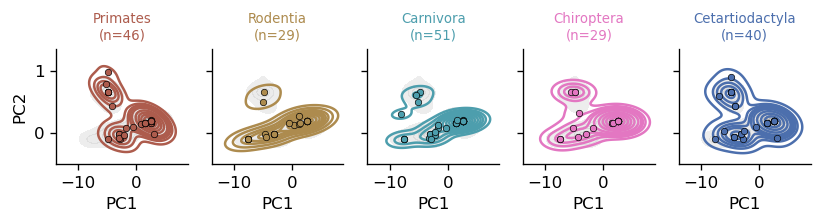

\begin{table}[ht]
\centering
\begin{tabular}{llccc}
\hline
\textbf{Order A} & \textbf{Order B} & $F$ & $p$ & Cohen's $d$ \\
\hline
Primates & Rodentia & 1.05 & 0.327 ns & 0.24 \\
Primates & Carnivora & 0.02 & 0.882 ns & 0.02 \\
Primates & Chiroptera & 0.18 & 0.674 ns & 0.10 \\
Primates & Cetartiodactyla & 1.47 & 0.242 ns & 0.26 \\
Rodentia & Carnivora & 1.16 & 0.279 ns & 0.25 \\
Rodentia & Chiroptera & 0.23 & 0.616 ns & 0.13 \\
Rodentia & Cetartiodactyla & 0.01 & 0.914 ns & 0.02 \\
Carnivora & Chiroptera & 0.25 & 0.629 ns & 0.12 \\
Carnivora & Cetartiodactyla & 1.66 & 0.184 ns & 0.27 \\
Chiroptera & Cetartiodactyla & 0.36 & 0.553 ns & 0.15 \\
\hline
\end{tabular}
\caption{Pairwise PERMANOVA (999 permutations) on the first two principal components. $F$: pseudo-$F$ statistic. $p$: permutation $p$-value. Cohen's $d$ computed on PC1. Significance: *** $p<0.001$, ** $p<0.01$, * $p<0.05$, ns $p\geq0.05$.}
\label{tab:permanova_orders}
\end{table}


In [13]:
from utils_permanova import run_permanova, sig_stars, print_latex_permanova_table
from itertools import combinations


orders_per_subject = [
    info_mami.iloc[i]["order"] if i < len(info_mami) else None
    for i in range(len(minima_eta))
]

eta_arr   = np.array(minima_eta)
gamma_arr = np.array(minima_gamma)
X_all     = np.stack([eta_arr, gamma_arr], axis=1)  # (n_subjects, 2)
labels    = np.array(orders_per_subject)

GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]

results = {}
for a, b in combinations(GROUPS_TO_INCLUDE, 2):
    m      = np.isin(labels, [a, b])
    X_, y_ = X_all[m], labels[m]
    if len(np.unique(y_)) < 2:
        continue
    F, p   = run_permanova(X_, y_)
    xa, xb = X_[y_ == a, 0], X_[y_ == b, 0]
    d      = abs(xa.mean() - xb.mean()) / np.sqrt((xa.var() + xb.var()) / 2 + 1e-9)
    results[(a, b)] = dict(F=F, p=p, d=d)
    # print(f"{a[:4]} vs {b[:4]}: F={F:.2f}  p={p:.4f}  d={d:.2f}")


# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 5,
    figsize=viz.cm_to_inch((18, 5)),
    gridspec_kw={"width_ratios": [1, 1, 1, 1, 1]},
    dpi=120, 
    sharex=True, sharey=True
)

# ── 4 KDE panels ──────────────────────────────────────────────────────────────
for ax, focal in zip(axes[:5], GROUPS_TO_INCLUDE):
    mask_focal  = labels == focal
    color_focal = color_dict[focal]

    # Background KDE — all four orders
    sns.kdeplot(x=X_all[:, 0], y=X_all[:, 1], ax=ax,
                fill=True, color="lightgray", alpha=0.3, zorder=1)

    # Focal KDE contour
    if mask_focal.sum() > 3:
        sns.kdeplot(x=X_all[mask_focal, 0], y=X_all[mask_focal, 1],
                    ax=ax, fill=False, color=color_focal, alpha=1, zorder=4)

    # Focal scatter
    ax.scatter(X_all[mask_focal, 0], X_all[mask_focal, 1],
               color=color_focal, s=15, edgecolors="black",
               linewidths=0.4, zorder=5)

    # ax.set_xlim(*square_x_lim)
    # ax.set_ylim(*square_y_lim)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2" if ax is axes[0] else "")
    ax.set_title(f"{focal}\n(n={mask_focal.sum()})", fontsize=8,
                 color=color_focal)
    ax.spines[["top", "right"]].set_visible(False)


# plt.suptitle("PCA space - phylogenetic order separation", fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig(output_path / "pca_kde_orders_permanova_mami_deltacon.pdf", bbox_inches="tight")
print(output_path / "pca_kde_orders_permanova_mami_deltacon.pdf")
plt.show()


print_latex_permanova_table(results, GROUPS_TO_INCLUDE, sig_stars)

In [20]:
# Create mask where info_mami["order"] is GROUPS_TO_INCLUDE
mask = info_mami["order"].isin(GROUPS_TO_INCLUDE)
filtered_info = info_mami[mask]
X_all_filtered = X_all[mask.values]
labels_filtered = labels[mask.values]

In [22]:
X_all_filtered.shape, labels_filtered.shape, filtered_info.shape

((195, 2), (195,), (195, 15))

Adjusted Rand Index : -0.003  (0=random, 1=perfect)
Normalized Mutual Info: 0.037  (0=random, 1=perfect)
Cluster          0  1  2   3  4  5
Order                             
Carnivora        4  8  8  27  0  3
Cetartiodactyla  2  4  4  18  5  5
Chiroptera       2  2  3  16  2  4
Primates         0  6  6  24  2  7
Rodentia         3  4  3  13  2  2


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_62663/2955564482.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = plt.cm.get_cmap("tab10", n_clusters)


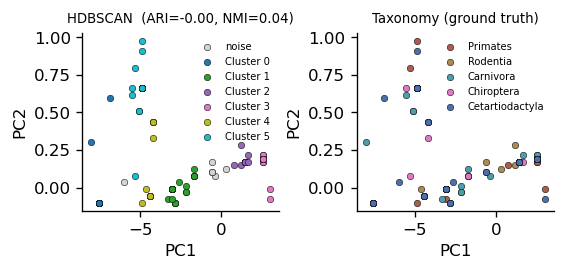

In [28]:
import hdbscan
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ── 1. Cluster (unsupervised — no labels used) ────────────────────────────────
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
cluster_labels = clusterer.fit_predict(X_all_filtered)   # -1 = noise points

# ── 2. Post-hoc alignment with taxonomy ──────────────────────────────────────
# Only compare on non-noise points
valid       = cluster_labels != -1
tax_labels  = labels_filtered[valid]        # ground-truth orders
clust_valid = cluster_labels[valid]

ari  = adjusted_rand_score(tax_labels, clust_valid)
nmi  = normalized_mutual_info_score(tax_labels, clust_valid)
print(f"Adjusted Rand Index : {ari:.3f}  (0=random, 1=perfect)")
print(f"Normalized Mutual Info: {nmi:.3f}  (0=random, 1=perfect)")

# Contingency table — which cluster contains which orders?
ct = pd.crosstab(tax_labels, clust_valid,
                 rownames=["Order"], colnames=["Cluster"])
print(ct)

# ── 3. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12, 6)), dpi=120)

# Left: HDBSCAN clusters
n_clusters   = len(set(clust_valid))
cluster_cmap = plt.cm.get_cmap("tab10", n_clusters)
for cid in np.unique(cluster_labels):
    m     = cluster_labels == cid
    color = "lightgray" if cid == -1 else cluster_cmap(cid)
    label = "noise" if cid == -1 else f"Cluster {cid}"
    axes[0].scatter(X_all_filtered[m, 0], X_all_filtered[m, 1],
                    color=color, s=15, edgecolors="black",
                    linewidths=0.3, label=label, zorder=2)
axes[0].set_title(f"HDBSCAN  (ARI={ari:.2f}, NMI={nmi:.2f})", fontsize=8)
axes[0].legend(fontsize=6, frameon=False)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].spines[["top", "right"]].set_visible(False)

# Right: taxonomy labels for comparison
for order in GROUPS_TO_INCLUDE: # color_dict.items():
    m = labels_filtered == order
    axes[1].scatter(X_all_filtered[m, 0], X_all_filtered[m, 1],
                    color=color_dict[order], s=15, edgecolors="black",
                    linewidths=0.3, label=order, zorder=2)
axes[1].set_title("Taxonomy (ground truth)", fontsize=8)
axes[1].legend(fontsize=6, frameon=False)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(output_path / "hdbscan_vs_taxonomy.pdf", bbox_inches="tight")
plt.show()